# Import libraries

In [3]:
import pandas as pd
import parquet
import pyarrow
import fastparquet
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 3000)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Import data

In [4]:
path = r"../data/processed/global_superstore_dataframe.parquet"

data_frame = pd.read_parquet(path = path, engine = "pyarrow")
print(data_frame["order_id"].nunique())
print(f"\n\nData successfully imported from: '{Path(path).resolve()}'\n\n")
data_frame.info()

25035


Data successfully imported from: 'D:\CURS\Proiecte analiza de date (angajare)\global-superstore\data\processed\global_superstore_dataframe.parquet'


<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 40 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   row_id           51290 non-null  int64         
 1   unique_order_id  51290 non-null  str           
 2   order_id         51290 non-null  str           
 3   order_priority   51290 non-null  category      
 4   order_date       51290 non-null  datetime64[us]
 5   order_day        51290 non-null  int8          
 6   order_month      51290 non-null  category      
 7   order_year       51290 non-null  int16         
 8   order_day_name   51290 non-null  category      
 9   is_weekend       51290 non-null  boolean       
 10  ship_date        51290 non-null  datetime64[us]
 11  ship_mode        51290 non-null  category      
 1

# Data analysis

### Order distribution

In [5]:
# TODO: exista o problema, trebuie sa faci groupby dupa [product_id, product_name] + [customer_id, customer_name]. Dc? Pentru ca exista produse / clienti cu acelasi nume dar id diferit
categorical_columns = [
    "order_priority",
    "order_day_name",
    "ship_mode",
    "segment",
    "market",
    "country",
    ["customer_id", "customer_name"]
]



print("\n--------DATA DISTRIBUTION--------\n")

for column in categorical_columns:
    print(f"{column} distribution")

    

    dist = data_frame.groupby(by = column).agg(
        orders_count = ("unique_order_id", lambda unique_order_id: unique_order_id.nunique()),
        returned_orders_count = ("unique_order_id", lambda unique_order_id: data_frame.loc[unique_order_id.index].loc[data_frame["returned"] == True, "unique_order_id"].nunique()),
        net_orders_count = ("unique_order_id", lambda unique_order_id: data_frame.loc[unique_order_id.index].loc[data_frame["returned"] == False, "unique_order_id"].nunique())
        )
    
   
    dist["%_from_total_orders"] = round((dist["net_orders_count"] / dist["net_orders_count"].sum()) * 100, 2)
    dist["%_return_rate"] = round(dist["returned_orders_count"] / (dist["orders_count"]) * 100, 2)
    dist = dist.sort_values(by="orders_count", ascending=False).reset_index()
  

    print(dist.head(50))
    print("\n")
    
print("------------------------------------------------------------\n")




# TODO
# Adauga coloane noi, cum ar fi media pentru shipping_cost, profitul total, cel mai mare discount / discount mediu
# De asemenea, sunt situatii cand avem nevoie de detalii in plus, cum ar fi categoria de produse pentru sub categorii, marketul la tari si tara de origine pentru fiecare client


--------DATA DISTRIBUTION--------

order_priority distribution
  order_priority  orders_count  returned_orders_count  net_orders_count  %_from_total_orders  %_return_rate
0         Medium         14736                    511             14225                57.25           3.47
1           High          7830                    279              7551                30.39           3.56
2       Critical          1973                     74              1899                 7.64           3.75
3            Low          1215                     43              1172                 4.72           3.54


order_day_name distribution
  order_day_name  orders_count  returned_orders_count  net_orders_count  %_from_total_orders  %_return_rate
0        Tuesday          4653                    150              4503                18.12           3.22
1         Monday          4633                    149              4484                18.05           3.22
2         Friday          4629            

### Product performance

In [6]:
df_no_returns = data_frame.loc[data_frame["returned"] == False]

# TODO: exista o problema, trebuie sa faci groupby dupa [product_id, product_name] + [customer_id, customer_name]. Dc? Pentru ca exista produse / clienti cu acelasi nume dar id diferit
categorical_columns = [
    "sub_category",
    "category",
    ["product_id", "product_name"]
]

df_temp = data_frame.copy()
df_temp["returned_product_line"] = None
df_temp.loc[df_temp["returned"] == True, "returned_product_line"] = df_temp["unique_order_id"]
df_temp["net_product_line"] = None
df_temp.loc[df_temp["returned"] == False, "net_product_line"] = df_temp["unique_order_id"]
df_temp["product_profit"] = None
df_temp.loc[df_temp["returned"] == False, "product_profit"] = df_temp["profit"]
df_temp["product_return_loss"] = None
df_temp.loc[df_temp["returned"] == True, "product_return_loss"] = df_temp["profit"]


print("\n--------PRODUCT PERFORMANCE--------\n")

print("Top 50 products by total profit (sales):")
print(df_no_returns.groupby(["product_id", "product_name"])["profit"].sum().sort_values(ascending=False).reset_index().head(50))

print("\n\n")

print("Worst 50 products by total profit (loss-makers):")
print(df_no_returns.groupby(["product_id", "product_name"])["profit"].sum().sort_values(ascending=True).reset_index().head(50))

print("\n\n")

for column in categorical_columns:
    print(f"{column} distribution")

    
    dist = df_temp.groupby(by = column).agg(
        products_count = ("unique_order_id", "count"),
        returned_products_count = ("returned_product_line", "count"),
        net_products_count = ("net_product_line", "count"),
        gross_profit = ("profit", "sum"),
        net_profit = ("product_profit", "sum"),
        return_loss = ("product_return_loss", "sum"),
        avg_discount = ("discount", "mean"),
        max_discount = ("discount", "max"),
        )
    
   
    dist["%_from_total_products"] = round((dist["net_products_count"] / dist["net_products_count"].sum()) * 100, 2)
    dist["%_return_rate"] = round(dist["returned_products_count"] / (dist["products_count"]) * 100, 2)
    dist = dist[["products_count", "returned_products_count", "net_products_count", "%_from_total_products", "%_return_rate","gross_profit", "net_profit", "return_loss", "avg_discount", "max_discount"]]
    dist = dist.sort_values(by="products_count", ascending=False).reset_index()
  

    print(dist.head(50))
    print("\n")

print("\n------------------------------------------------------------\n")


# TODO
# Adauga grupari si dupa categorii si sub categorii. 
# Pentru categorii si sub categorii, pe langa sa verifici profitul total la toate, ai putea calcula cat % din produse aduc profit si cat % din produse aduc pierderi
# Adauga o coloana noua pentru produse care sa arate cati bani s-au pierdut din produsele returnate
# Adauga o coloana noua care sa arata pretul mediu al transportului
# Adauga o coloana care arata cate produse din total ai discount si cate produse din total au discount care depaseste media


--------PRODUCT PERFORMANCE--------

Top 50 products by total profit (sales):
          product_id                                       product_name   profit
0    TEC-CO-10004722              Canon imageCLASS 2200 Advanced Copier 25199.93
1    TEC-PH-10004823                       Nokia Smart Phone, Full Size  8121.48
2    OFF-BI-10003527  Fellowes PB500 Electric Punch Plastic Comb Bin...  7753.04
3    TEC-CO-10001449               Hewlett Packard LaserJet 3310 Copier  6983.88
4    OFF-AP-10004512                                  Hoover Stove, Red  6366.50
5    FUR-CH-10002250      Office Star Executive Leather Armchair, Black  6123.26
6    TEC-PH-10004664                  Nokia Smart Phone, with Caller ID  5455.95
7    OFF-AP-10002330                       Hamilton Beach Stove, Silver  5452.46
8    FUR-CH-10002203            SAFCO Executive Leather Armchair, Black  5003.10
9    TEC-PH-10000169                  Apple Smart Phone, with Caller ID  4954.15
10   FUR-BO-10004852          

### Return analysis

In [7]:
print("\n--------RETURNS ANALYSIS--------\n")

print("Return rate by category:")
print(data_frame.groupby("category")["returned"].mean())

print("\n")

print("Return rate by shipping mode:")
print(data_frame.groupby("ship_mode")["returned"].mean())

print("\n")

print("Total returned items per category")
print(data_frame.groupby("category")["returned"].sum().reset_index().sort_values(by = "returned", ascending = False))

print("\n")

print("Total returned items per segment")
print(data_frame.groupby("segment")["returned"].sum().reset_index().sort_values(by = "returned", ascending = False))

print("\n")

print("Total returned products, orders and items")
df_return_dist = data_frame.groupby("returned").agg(
    orders_count = ("unique_order_id", "nunique"),
    products_count = ("unique_order_id", "count"),
    quantity_count = ("quantity", "sum")
).reset_index().sort_values(by = "orders_count", ascending = False)
print(df_return_dist)

print("\n------------------------------------------------------------\n")


# TODO
# Sa calculez "Total returned items" si pe tari, market, clienti si sub categorii. 
# La tari si clienti, unde sunt multe valori, sa le iau in calcul doar pe cele care chiar au returnat. Si de asemenea, sa fac un top 50 pentru fiecare
# Calculeaza return rate pentru df_return_dist


--------RETURNS ANALYSIS--------

Return rate by category:
category
Furniture         0.05
Office Supplies   0.04
Technology        0.05
Name: returned, dtype: Float64


Return rate by shipping mode:
ship_mode
First Class      0.05
Same Day         0.04
Second Class     0.05
Standard Class   0.04
Name: returned, dtype: Float64


Total returned items per category
          category  returned
1  Office Supplies      1310
2       Technology       467
0        Furniture       466


Total returned items per segment
       segment  returned
0     Consumer      1151
1    Corporate       712
2  Home Office       380


Total returned products, orders and items
   returned  orders_count  products_count  quantity_count
0     False         24847           49047          169620
1      True           907            2243            8692

------------------------------------------------------------



### Profit analysis

In [8]:
df = data_frame.loc[data_frame["returned"] == False]

print("\n--------PROFIT ANALYSIS--------\n")

print("Total profit by category:")
print(df.groupby("category")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by market:")
print(df.groupby("market")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by segment:")
print(df.groupby("segment")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by sub_category:")
print(df.groupby("sub_category")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by order_priority:")
print(df.groupby("order_priority")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by country (top 10):")
print(df.groupby("country")["profit"].sum().reset_index().sort_values(by = "profit", ascending = False).head(10))

print("\n")

print("Total profit by country (last 10):")
print(df.groupby("country")["profit"].sum().reset_index().sort_values(by = "profit", ascending = True).head(10))

print("\n------------------------------------------------------------\n")


# TODO
# Adauga o coloana noua care sa arate cati bani s-au pierdut din produsele returnate
# Adauga o coloana noua care sa arata pretul mediu al transportului
# Adauga o coloana noua care sa arate medie discouturilor
# Adauga o coloana noua care sa arate discountul cel mai mare


--------PROFIT ANALYSIS--------

Total profit by category:
          category    profit
2       Technology 623635.62
1  Office Supplies 484181.75
0        Furniture 264704.59


Total profit by market:
   market    profit
0    APAC 390847.84
4      EU 344111.25
6      US 286397.03
5   LATAM 205001.75
1  Africa  88871.63
3    EMEA  39475.10
2  Canada  17817.39


Total profit by segment:
       segment    profit
0     Consumer 709720.38
1    Corporate 403475.53
2  Home Office 259326.08


Total profit by sub_category:
   sub_category    profit
6       Copiers 243215.09
13       Phones 204221.73
4     Bookcases 148922.44
5        Chairs 132764.53
1    Appliances 125608.48
0   Accessories 120968.79
14      Storage 103949.73
3       Binders  70105.91
12        Paper  57669.00
11     Machines  55230.00


Total profit by order_priority:
  order_priority    profit
3         Medium 811380.56
1           High 390163.56
0       Critical 119205.42
2            Low  51772.39


Total profit by countr

### Correlations

In [9]:
df = data_frame.loc[data_frame["returned"] == False]

print("\n--------CORRELATIONS--------\n")

print("Relationship between profit and discount")
print(df[["profit", "discount"]].corr())

print("\n")

print("Relationship between profit and shipping cost")
print(df[["profit", "shipping_cost"]].corr())

print("\n")

print("Relationship between profit and quantity")
print(df[["profit", "quantity"]].corr())

print("\n")

print("Relationship between profit and total cost, product cost and shipping cost")
print(df[["profit", "cost", "product_cost", "shipping_cost"]].corr())

print("\n")

print("Relationship between sales and discount")
print(df[["sales", "discount"]].corr())

print("\n")

print("Relationship between delivery time and shipping cost")
print(df[["delivery_time", "shipping_cost"]].corr())

print("\n")

print("Relationship between profit sales and shipping ratio")
print(df[["profit", "shipping_ratio"]].corr())

print("\n")

print("Relationship between quantity and shipping cost")
print(df[["quantity", "shipping_cost"]].corr())

print("\n------------------------------------------------------------\n")


# TODO
# Grupeaza datele dupa aceste etichete si dupa verifica corelatia dintre date la fiecare eticheta: market, segment, ship_mode, tari, categorii, sub categorii


--------CORRELATIONS--------

Relationship between profit and discount
          profit  discount
profit      1.00     -0.32
discount   -0.32      1.00


Relationship between profit and shipping cost
               profit  shipping_cost
profit           1.00           0.35
shipping_cost    0.35           1.00


Relationship between profit and quantity
          profit  quantity
profit      1.00      0.10
quantity    0.10      1.00


Relationship between profit and total cost, product cost and shipping cost
               profit  cost  product_cost  shipping_cost
profit           1.00  0.14          0.10           0.35
cost             0.14  1.00          0.99           0.72
product_cost     0.10  0.99          1.00           0.65
shipping_cost    0.35  0.72          0.65           1.00


Relationship between sales and discount
          sales  discount
sales      1.00     -0.09
discount  -0.09      1.00


Relationship between delivery time and shipping cost
               delivery_tim

### Discount analysis

Discount overview

Min discount: 0.0
p25 discount: 0.0
Median discount: 0.0
p75 discount: 0.2
Max discount: 0.85
Avg discount: 0.14
Products with discount count: 21437
Products without discount count: 27610
Products with discount (%): 43.71
Actual profit: 1372522.0
Profit without discount: 3654135.0
Total discount given: 2281613.0
Profit erosion (%): 62.44
Profit discount correlation: -0.32
Profit margin discount correlation: -0.85
Quantity discount correlation: -0.02
Shipping cost discount correlation: -0.08
Avg discount value per discounted product: 106.43
Actual profit margin (%): 11.43
Potential profit margin (%): 25.58

-----------------------------------------------------------------------


Group by order_priority
  order_priority  min_discount  p25_discount  median_discount  p75_discount  max_discount  avg_discount  products_has_discount_count  products_without_discount  actual_profit  profit_without_discount  total_discount_given  %_products_has_discount  profit_erosion_%
0   

c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Stefan\AppData\Local\Programs\Python\Python314\Lib\

   sub_category  profit_discount_correlation  profit_margin_discount_correlation  quantity_discount_correlation  shipping_cost_discount_correlation
3       Binders                        -0.17                               -0.89                           0.02                               -0.04
6       Copiers                        -0.34                               -0.83                          -0.05                               -0.17
10       Labels                        -0.39                               -0.83                          -0.03                               -0.15
11     Machines                        -0.41                               -0.87                          -0.04                               -0.12
0   Accessories                        -0.42                               -0.83                          -0.03                               -0.13
1    Appliances                        -0.43                               -0.88                          -0.03 

C:\Users\Stefan\AppData\Local\Temp\ipykernel_12080\2927663868.py:166: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


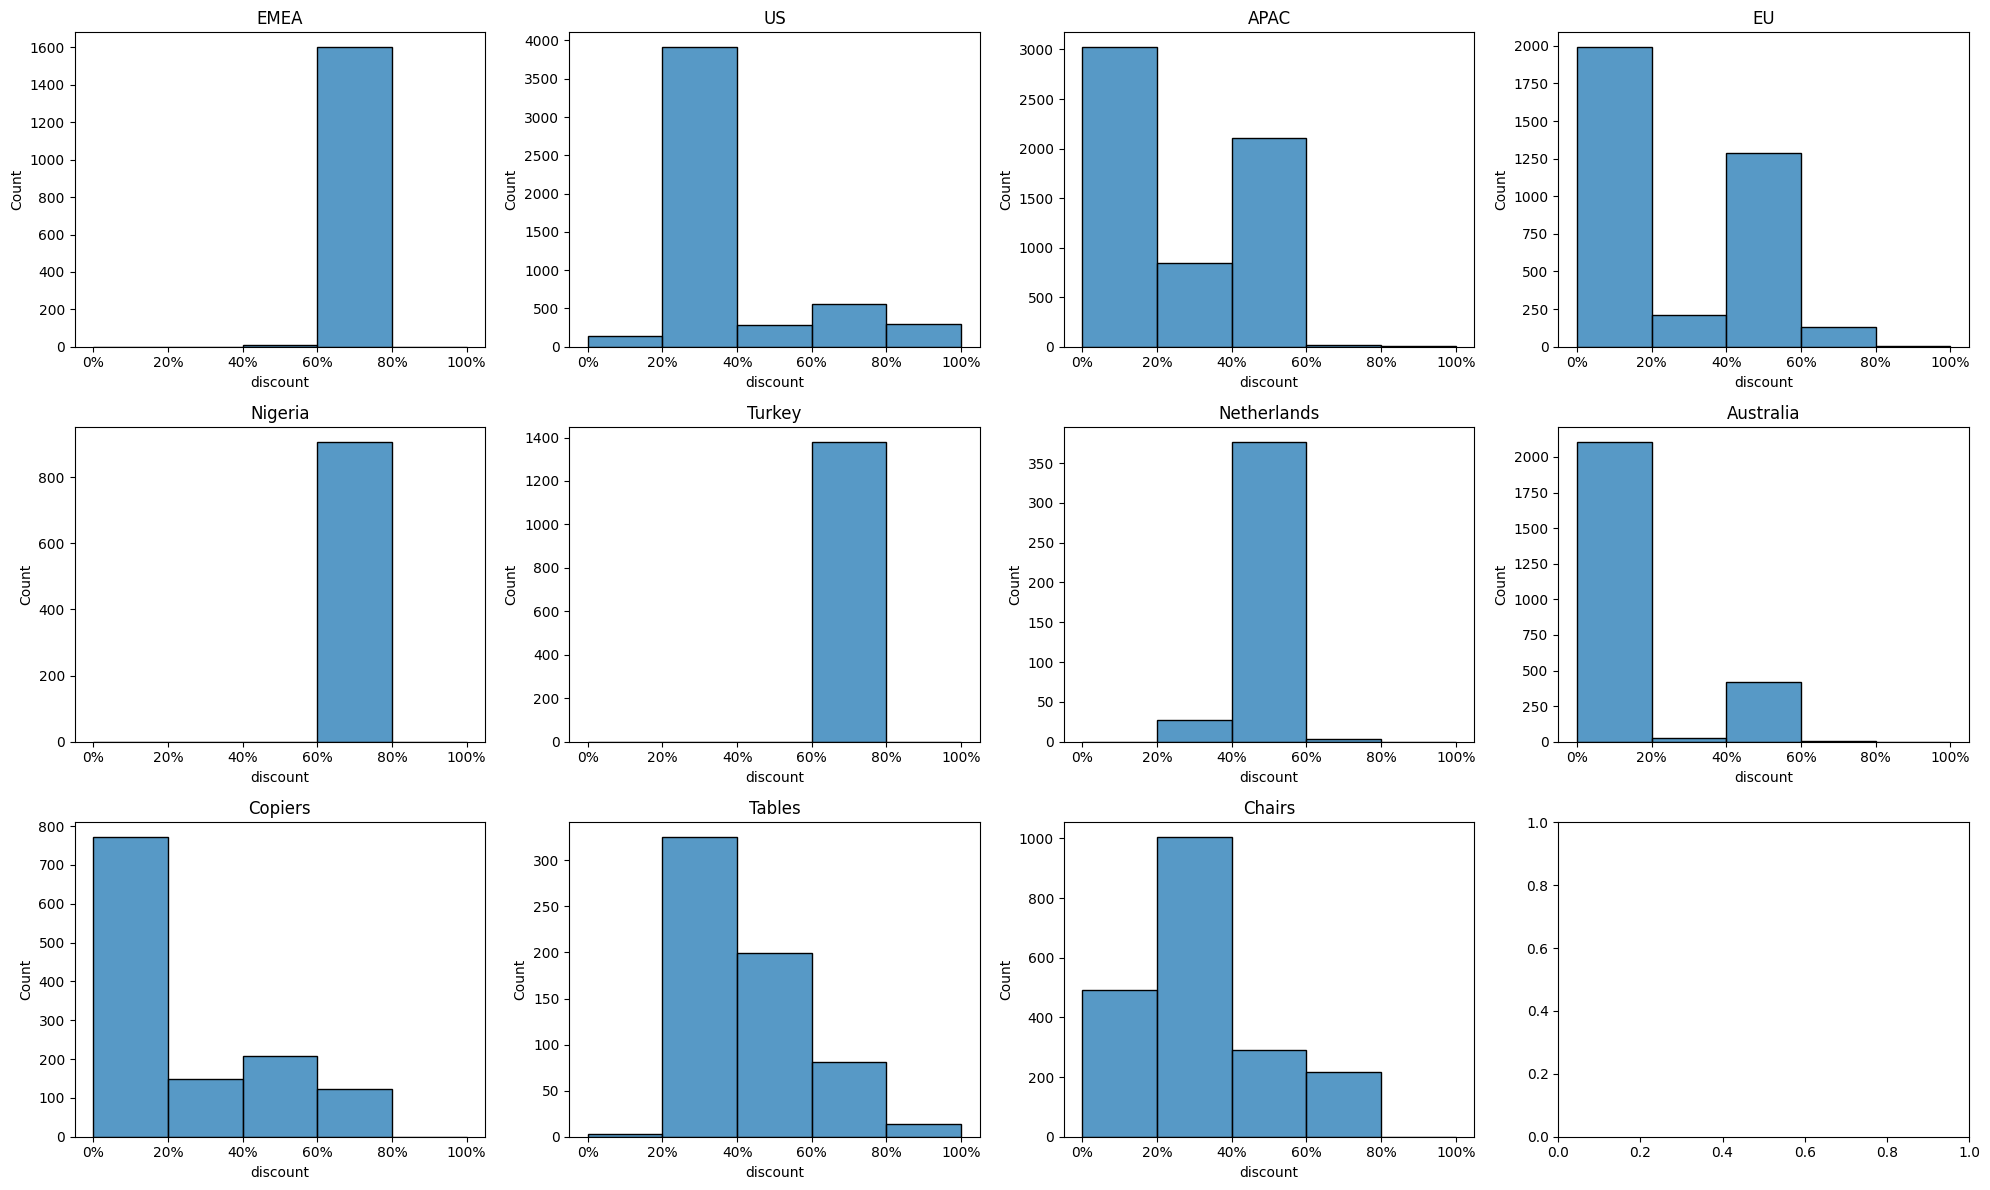

In [10]:
df = data_frame.loc[data_frame["returned"] == False].copy()

print("Discount overview\n")
min_discount = df["discount"].min()
p25_discount = df["discount"].quantile(0.25) 
median_discount = df["discount"].median() 
p75_discount = round(float(df["discount"].quantile(0.75)), 2)
max_discount = round(float(df["discount"].max()), 2)  
avg_discount = round(float(df["discount"].mean()), 2) 
products_has_discount_count = df.loc[df["discount"] > 0]["order_id"].count()
products_without_discount = df.loc[df["discount"] == 0]["order_id"].count()  
actual_profit = df["profit"].sum()
profit_without_discount = df["profit"].sum() + df["discount_value"].sum()
total_discount_given = df["discount_value"].sum()
products_has_discount = round(float((products_has_discount_count / (products_has_discount_count + products_without_discount))) * 100, 2)
profit_erosion = round(float((total_discount_given / profit_without_discount)) * 100, 2)
profit_discount_correlation = round(float(df["discount"].corr(df["profit"])), 2)
profit_margin_discount_correlation = round(float(df["discount"].corr(df["profit_margin"])), 2)
quantity_discount_correlation = round(float(df["discount"].corr(df["quantity"])), 2)  
shipping_cost_discount_correlation = round(float(df["discount"].corr(df["shipping_cost"])), 2)
avg_discount_value_per_discounted_product = round(float(df["discount_value"].sum() / products_has_discount_count), 2)
actual_profit_margin = round(float(df["profit"].sum() / df["sales"].sum()) * 100, 2)
potential_profit_margin = round(float((df["profit"].sum() + df["discount_value"].sum()) / (df["sales"].sum() + df["discount_value"].sum())) * 100, 2)

print(f"Min discount: {min_discount}")
print(f"p25 discount: {p25_discount}")
print(f"Median discount: {median_discount}")
print(f"p75 discount: {p75_discount}")
print(f"Max discount: {max_discount}")
print(f"Avg discount: {avg_discount}")
print(f"Products with discount count: {products_has_discount_count}")
print(f"Products without discount count: {products_without_discount}")
print(f"Products with discount (%): {products_has_discount}")
print(f"Actual profit: {actual_profit}")
print(f"Profit without discount: {profit_without_discount}")
print(f"Total discount given: {total_discount_given}")
print(f"Profit erosion (%): {profit_erosion}")
print(f"Profit discount correlation: {profit_discount_correlation}")
print(f"Profit margin discount correlation: {profit_margin_discount_correlation}")
print(f"Quantity discount correlation: {quantity_discount_correlation}")
print(f"Shipping cost discount correlation: {shipping_cost_discount_correlation}")
print(f"Avg discount value per discounted product: {avg_discount_value_per_discounted_product}")
print(f"Actual profit margin (%): {actual_profit_margin}")
print(f"Potential profit margin (%): {potential_profit_margin}")


print("\n-----------------------------------------------------------------------\n\n")


df_discount_statistics = df.copy()

categorical_groupby_configs = [
    {"target_col": "order_priority", "parent_col": None},
    {"target_col": "order_day_name", "parent_col": None},
    {"target_col": "ship_mode", "parent_col": None},
    {"target_col": "segment", "parent_col": None},
    {"target_col": "market", "parent_col": None},
    {"target_col": "country", "parent_col": "market"},
    {"target_col": ["customer_id", "customer_name"], "parent_col": None},
    {"target_col": "sub_category", "parent_col": "category"},
    {"target_col": "category", "parent_col": None},
    {"target_col": ["product_id", "product_name"], "parent_col": "category"},
    {"target_col": "order_year", "parent_col": None},
]

df_discount_statistics["has_discount"] = df_discount_statistics["discount"] > 0
df_discount_statistics["profit_without_discount"] = df_discount_statistics["profit"] + df_discount_statistics["discount_value"]

for column in categorical_groupby_configs:
    print(f"Group by {column["target_col"]}")

    df_group = df_discount_statistics.groupby(by = column["target_col"]).agg(
        min_discount = ("discount", "min"),
        p25_discount = ("discount", lambda discount_series: discount_series.quantile(0.25)),
        median_discount = ("discount", "median"),
        p75_discount = ("discount", lambda discount_series: discount_series.quantile(0.75)),
        max_discount = ("discount", "max"),
        avg_discount = ("discount", "mean"),
        products_has_discount_count = ("has_discount", "sum"),
        products_without_discount = ("has_discount", lambda has_discount_series: (~has_discount_series).sum()),
        actual_profit = ("profit", "sum"),
        profit_without_discount = ("profit_without_discount", "sum"),
        total_discount_given = ("discount_value", "sum")
    ).reset_index()

    df_group["%_products_has_discount"] = round(df_group["products_has_discount_count"] / (df_group["products_has_discount_count"] + df_group["products_without_discount"]) * 100, 2)
    df_group["profit_erosion_%"] = round((df_group["total_discount_given"] / df_group["profit_without_discount"]) * 100, 2)

    if column["parent_col"] != None:
        if isinstance(column["target_col"], list):
            target_col = column["target_col"][0]
        else:
            target_col = column["target_col"]
        mapping_df = df[[target_col, column["parent_col"]]].drop_duplicates()
        df_group = df_group.merge(mapping_df, on = target_col, how="left")

   
    print(df_group.sort_values(by = "profit_erosion_%", ascending = True).head(25))
    
    print("\n\n")


print("\n-----------------------------------------------------------------------\n\n")

df_discount_correlations = df.copy()

correlation_categorical_columns = [
    "order_priority",
    "order_day_name",
    "ship_mode",
    "segment",
    "market",
    "sub_category",
    "category",
    "order_year"
]

for column in correlation_categorical_columns:
    print(f"Group by {column}")

    df_group = df_discount_correlations.groupby(by = column).agg(
        profit_discount_correlation = ("discount", lambda discount_series: df_discount_correlations.loc[discount_series.index]["profit"].corr(discount_series)),
        profit_margin_discount_correlation = ("discount", lambda discount_series: df_discount_correlations.loc[discount_series.index]["profit_margin"].corr(discount_series)),
        quantity_discount_correlation = ("discount", lambda discount_series: df_discount_correlations.loc[discount_series.index]["quantity"].corr(discount_series)),
        shipping_cost_discount_correlation = ("discount", lambda discount_series: df_discount_correlations.loc[discount_series.index]["shipping_cost"].corr(discount_series))
    ).reset_index()


    print(df_group.sort_values(by = "profit_discount_correlation", ascending = False).head(25))

    print("\n\n")


print("\n-----------------------------------------------------------------------\n\n")



histograms_configs = {
    "market": ["EMEA", "US", "APAC", "EU"], 
    "country": ["Nigeria", "Turkey", "Netherlands", "Australia"], 
    "sub_category": ["Copiers", "Tables", "Chairs"]
}

bins = [x for x in np.arange(0, 1.2, 0.2)]
labels = [f"{int(x)}%" for x in np.arange(0, 120, 20)]

figure, axes = plt.subplots(3, 4, figsize=(20, 12))

i = 0
y = 0

for key, values in histograms_configs.items():
    for value in values:
        df_discount_histogram = df_discount_statistics.loc[df_discount_statistics[key] == value]
        df_discount_histogram = df_discount_histogram.loc[df_discount_histogram["discount"] > 0]

        histogram = sns.histplot(data = df_discount_histogram, x = "discount", bins = bins, ax = axes[i][y])
        histogram.set_xticks(ticks = bins, labels = labels)
        histogram.set_title(label = value)
        y+=1
    i+=1
    y = 0


figure.tight_layout()
figure.show()

### Discount & Delivery impact

In [11]:
print("\n--------DISCOUNT & DELIVERY IMPACT--------\n")

print("Average discount for returned vs non-returned orders:")
print(data_frame.groupby("returned")["discount"].mean())

print("\n")

print("Average delivery time for returned vs non-returned orders:")
print(data_frame.groupby("returned")["delivery_time"].mean())

print("\n")

# Adauga cate informatii in plus: cel mai scump transport (max shipping cost), profitul average (mean), discount average (mean), max discount (max), total discount value (sum), numarul total de discounturi aplicate pe produse + numarul total de produse vandute fara discount
print(f"Average shipping cost per subcategories:")
print(data_frame.loc[data_frame["returned"] == False].groupby("sub_category")["shipping_cost"].mean().reset_index().sort_values(by = "shipping_cost", ascending = False).head(25))


print("\n------------------------------------------------------------\n")


# TODO
# Mai multe informatii si analize pentru discount si delivery


--------DISCOUNT & DELIVERY IMPACT--------

Average discount for returned vs non-returned orders:
returned
False   0.14
True    0.10
Name: discount, dtype: float32


Average delivery time for returned vs non-returned orders:
returned
False   3.97
True    3.94
Name: delivery_time, dtype: float64


Average shipping cost per subcategories:
   sub_category  shipping_cost
16       Tables          93.17
6       Copiers          71.52
4     Bookcases          63.98
1    Appliances          60.27
13       Phones          54.98
11     Machines          53.28
5        Chairs          47.68
0   Accessories          27.16
14      Storage          23.57
9   Furnishings          12.72
15     Supplies          10.10
2           Art           8.34
3       Binders           7.84
7     Envelopes           7.55
12        Paper           7.48
8     Fasteners           3.70
10       Labels           3.09

------------------------------------------------------------



### Key Business Metrics Summary

In [12]:
df = data_frame.loc[data_frame["returned"] == False].copy()

total_rows = data_frame.shape[0]
total_columns = data_frame.shape[1]
total_days = data_frame["order_date"].nunique()

total_orders_gross = data_frame["unique_order_id"].nunique()
total_orders_net = df["unique_order_id"].nunique()

total_customers = df["customer_id"].nunique()
total_products = df["product_id"].nunique()
total_quantity_sold = df["quantity"].sum()
total_countries = df["country"].nunique()

total_sales = df["sales"].sum()
total_profit = df["profit"].sum()

avg_orders_per_customer = round(total_orders_net / total_customers, 2)
avg_products_per_customer = round(total_quantity_sold / total_customers, 2)
avg_revenue_per_customer = round(float(total_sales / total_customers), 2)
avg_profit_per_customer = round(float(total_profit / total_customers), 2)

avg_products_per_order = round(total_quantity_sold / total_orders_net, 2)
avg_unique_products_per_order = round(df.groupby("unique_order_id")["product_id"].nunique().mean(), 2)
avg_revenue_per_order = round(float(total_sales / total_orders_net), 2)
avg_profit_per_order = round(float(total_profit / total_orders_net), 2)

profit_margin = round(float(total_profit / total_sales) * 100, 2)

returned_df = data_frame.loc[data_frame["returned"] == True]
total_returned_loss = returned_df["profit"].sum()
total_returned_orders = returned_df["unique_order_id"].nunique()
total_returned_items = returned_df.shape[0]
total_returned_quantity = returned_df["quantity"].sum()
return_rate = round(float(total_returned_orders / total_orders_gross) * 100, 2)

profit_percentage = round((df.loc[df["profit"] > 0].shape[0] / df.shape[0]) * 100, 2)
loss_percentage = round((df.loc[df["profit"] <= 0].shape[0] / df.shape[0]) * 100, 2)

print("\n--------KEY BUSINESS METRICS SUMMARY--------\n")

print(f"Dataset size: {total_rows} rows X {total_columns} columns")
print(f"Time span: {total_days} unique days")
print(f"Total net orders: {total_orders_net} (Gross: {total_orders_gross})")
print(f"Total countries: {total_countries}")
print(f"Profit distribution (lines): {profit_percentage}% profit, {loss_percentage}% loss")

print("\nCustomer info:")
print(f"- Average orders per customer: {avg_orders_per_customer}")
print(f"- Average products per customer: {avg_products_per_customer}")
print(f"- Average revenue per customer: {avg_revenue_per_customer}")
print(f"- Average profit per customer: {avg_profit_per_customer}")

print("\nOrder info:")
print(f"- Average products per order: {avg_products_per_order}")
print(f"- Average unique products per order: {avg_unique_products_per_order}")
print(f"- Average revenue per order: {avg_revenue_per_order}")
print(f"- Average profit per order: {avg_profit_per_order}")
print(f"- Profit margin: {profit_margin}%")

print("\nReturns:")
print(f"- Return rate: {return_rate}%")
print(f"- Total returned loss: {total_returned_loss}")
print(f"- Total returned orders: {total_returned_orders}")
print(f"- Total returned items: {total_returned_items}")
print(f"- Total returned quantity: {total_returned_quantity}")

print("\nInventory:")
print(f"- Unique customers: {total_customers}")
print(f"- Unique products: {total_products}")
print(f"- Total quantity sold: {total_quantity_sold}")

print("\n------------------------------------------------------------\n")


--------KEY BUSINESS METRICS SUMMARY--------

Dataset size: 51290 rows X 40 columns
Time span: 1430 unique days
Total net orders: 24847 (Gross: 25754)
Total countries: 147
Profit distribution (lines): 74.12% profit, 25.88% loss

Customer info:
- Average orders per customer: 15.63
- Average products per customer: 106.68
- Average revenue per customer: 7550.29
- Average profit per customer: 863.22

Order info:
- Average products per order: 6.83
- Average unique products per order: 1.97
- Average revenue per order: 483.16
- Average profit per order: 55.24
- Profit margin: 11.43%

Returns:
- Return rate: 3.52%
- Total returned loss: 94935.328125
- Total returned orders: 907
- Total returned items: 2243
- Total returned quantity: 8692

Inventory:
- Unique customers: 1590
- Unique products: 10227
- Total quantity sold: 169620

------------------------------------------------------------



### Statistics

In [13]:
df = data_frame.loc[data_frame["returned"] == False].copy()

print("\n--------NUMERICAL FEATURES SUMMARY--------\n")

print(df[[
    "delivery_time", "quantity", "original_price", "discount",
    "discount_value", "sales", "profit", "profit_margin",
    "cost", "shipping_cost", "product_cost",
    "shipping_ratio", "cost_ratio"
]].describe())

print("\n------------------------------------------------------------\n")



print("\n--------DATASET INFO--------\n")
data_frame.info()
print("\n------------------------------------------------------------\n")


data_frame.head(5)


--------NUMERICAL FEATURES SUMMARY--------

       delivery_time  quantity  original_price  discount  discount_value    sales   profit  profit_margin     cost  shipping_cost  product_cost  shipping_ratio  cost_ratio
count       49047.00  49047.00        49047.00  49047.00        49047.00 49047.00 49047.00       49047.00 49047.00       49047.00      49047.00        49047.00    49047.00
mean            3.97      3.46          291.28      0.14           46.52   244.76    27.98           0.04   216.78          26.17        190.61            0.11        0.96
std             1.73      2.28          603.59      0.21          212.55   487.62   174.30           0.47   432.48          57.19        393.17            0.07        0.47
min             0.00      1.00            0.99      0.00            0.00     0.44 -6599.98          -4.73     0.55           0.00          0.36            0.00        0.50
25%             3.00      2.00           37.89      0.00            0.00    30.30     0.00     

,row_id,unique_order_id,order_id,order_priority,order_date,order_day,order_month,order_year,order_day_name,is_weekend,ship_date,ship_mode,delivery_time,customer_id,customer_name,segment,city,state,country,postal_code,market,region,product_id,category,sub_category,product_name,quantity,original_price,discount,discount_value,sales,profit,profit_margin,cost,shipping_cost,product_cost,shipping_ratio,cost_ratio,employee,returned
0,32298,CA-2012-124891_RH-19495_2012-07-31,CA-2012-124891,Critical,2012-07-31,31,July,2012,Tuesday,False,2012-07-31,Same Day,0,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,7,2309.65,0.00,0.00,2309.65,762.18,0.33,1547.47,933.57,613.90,0.40,0.67,Kelly Williams,False
1,26341,IN-2013-77878_JR-16210_2013-02-05,IN-2013-77878,Critical,2013-02-05,5,February,2013,Tuesday,False,2013-02-07,Second Class,2,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,Unknown,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",9,4121.55,0.10,412.16,3709.40,-288.77,-0.08,3998.16,923.63,3074.53,0.25,1.08,Anthony Jacobs,True
2,25330,IN-2013-71249_CR-12730_2013-10-17,IN-2013-71249,Medium,2013-10-17,17,October,2013,Thursday,False,2013-10-18,First Class,1,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,Unknown,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",9,5750.19,0.10,575.02,5175.17,919.97,0.18,4255.20,915.49,3339.71,0.18,0.82,Anthony Jacobs,False
3,13524,ES-2013-1579342_KM-16375_2013-01-28,ES-2013-1579342,Medium,2013-01-28,28,January,2013,Monday,False,2013-01-30,First Class,2,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,Unknown,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",5,3213.90,0.10,321.39,2892.51,-96.54,-0.03,2989.05,910.16,2078.89,0.31,1.03,Anna Andreadi,False
4,47221,SG-2013-4320_RH-9495_2013-11-05,SG-2013-4320,Critical,2013-11-05,5,November,2013,Tuesday,False,2013-11-06,Same Day,1,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,Unknown,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",8,2832.96,0.00,0.00,2832.96,311.52,0.11,2521.44,903.04,1618.40,0.32,0.89,Deborah Brumfield,False


### Seaborn pairplot

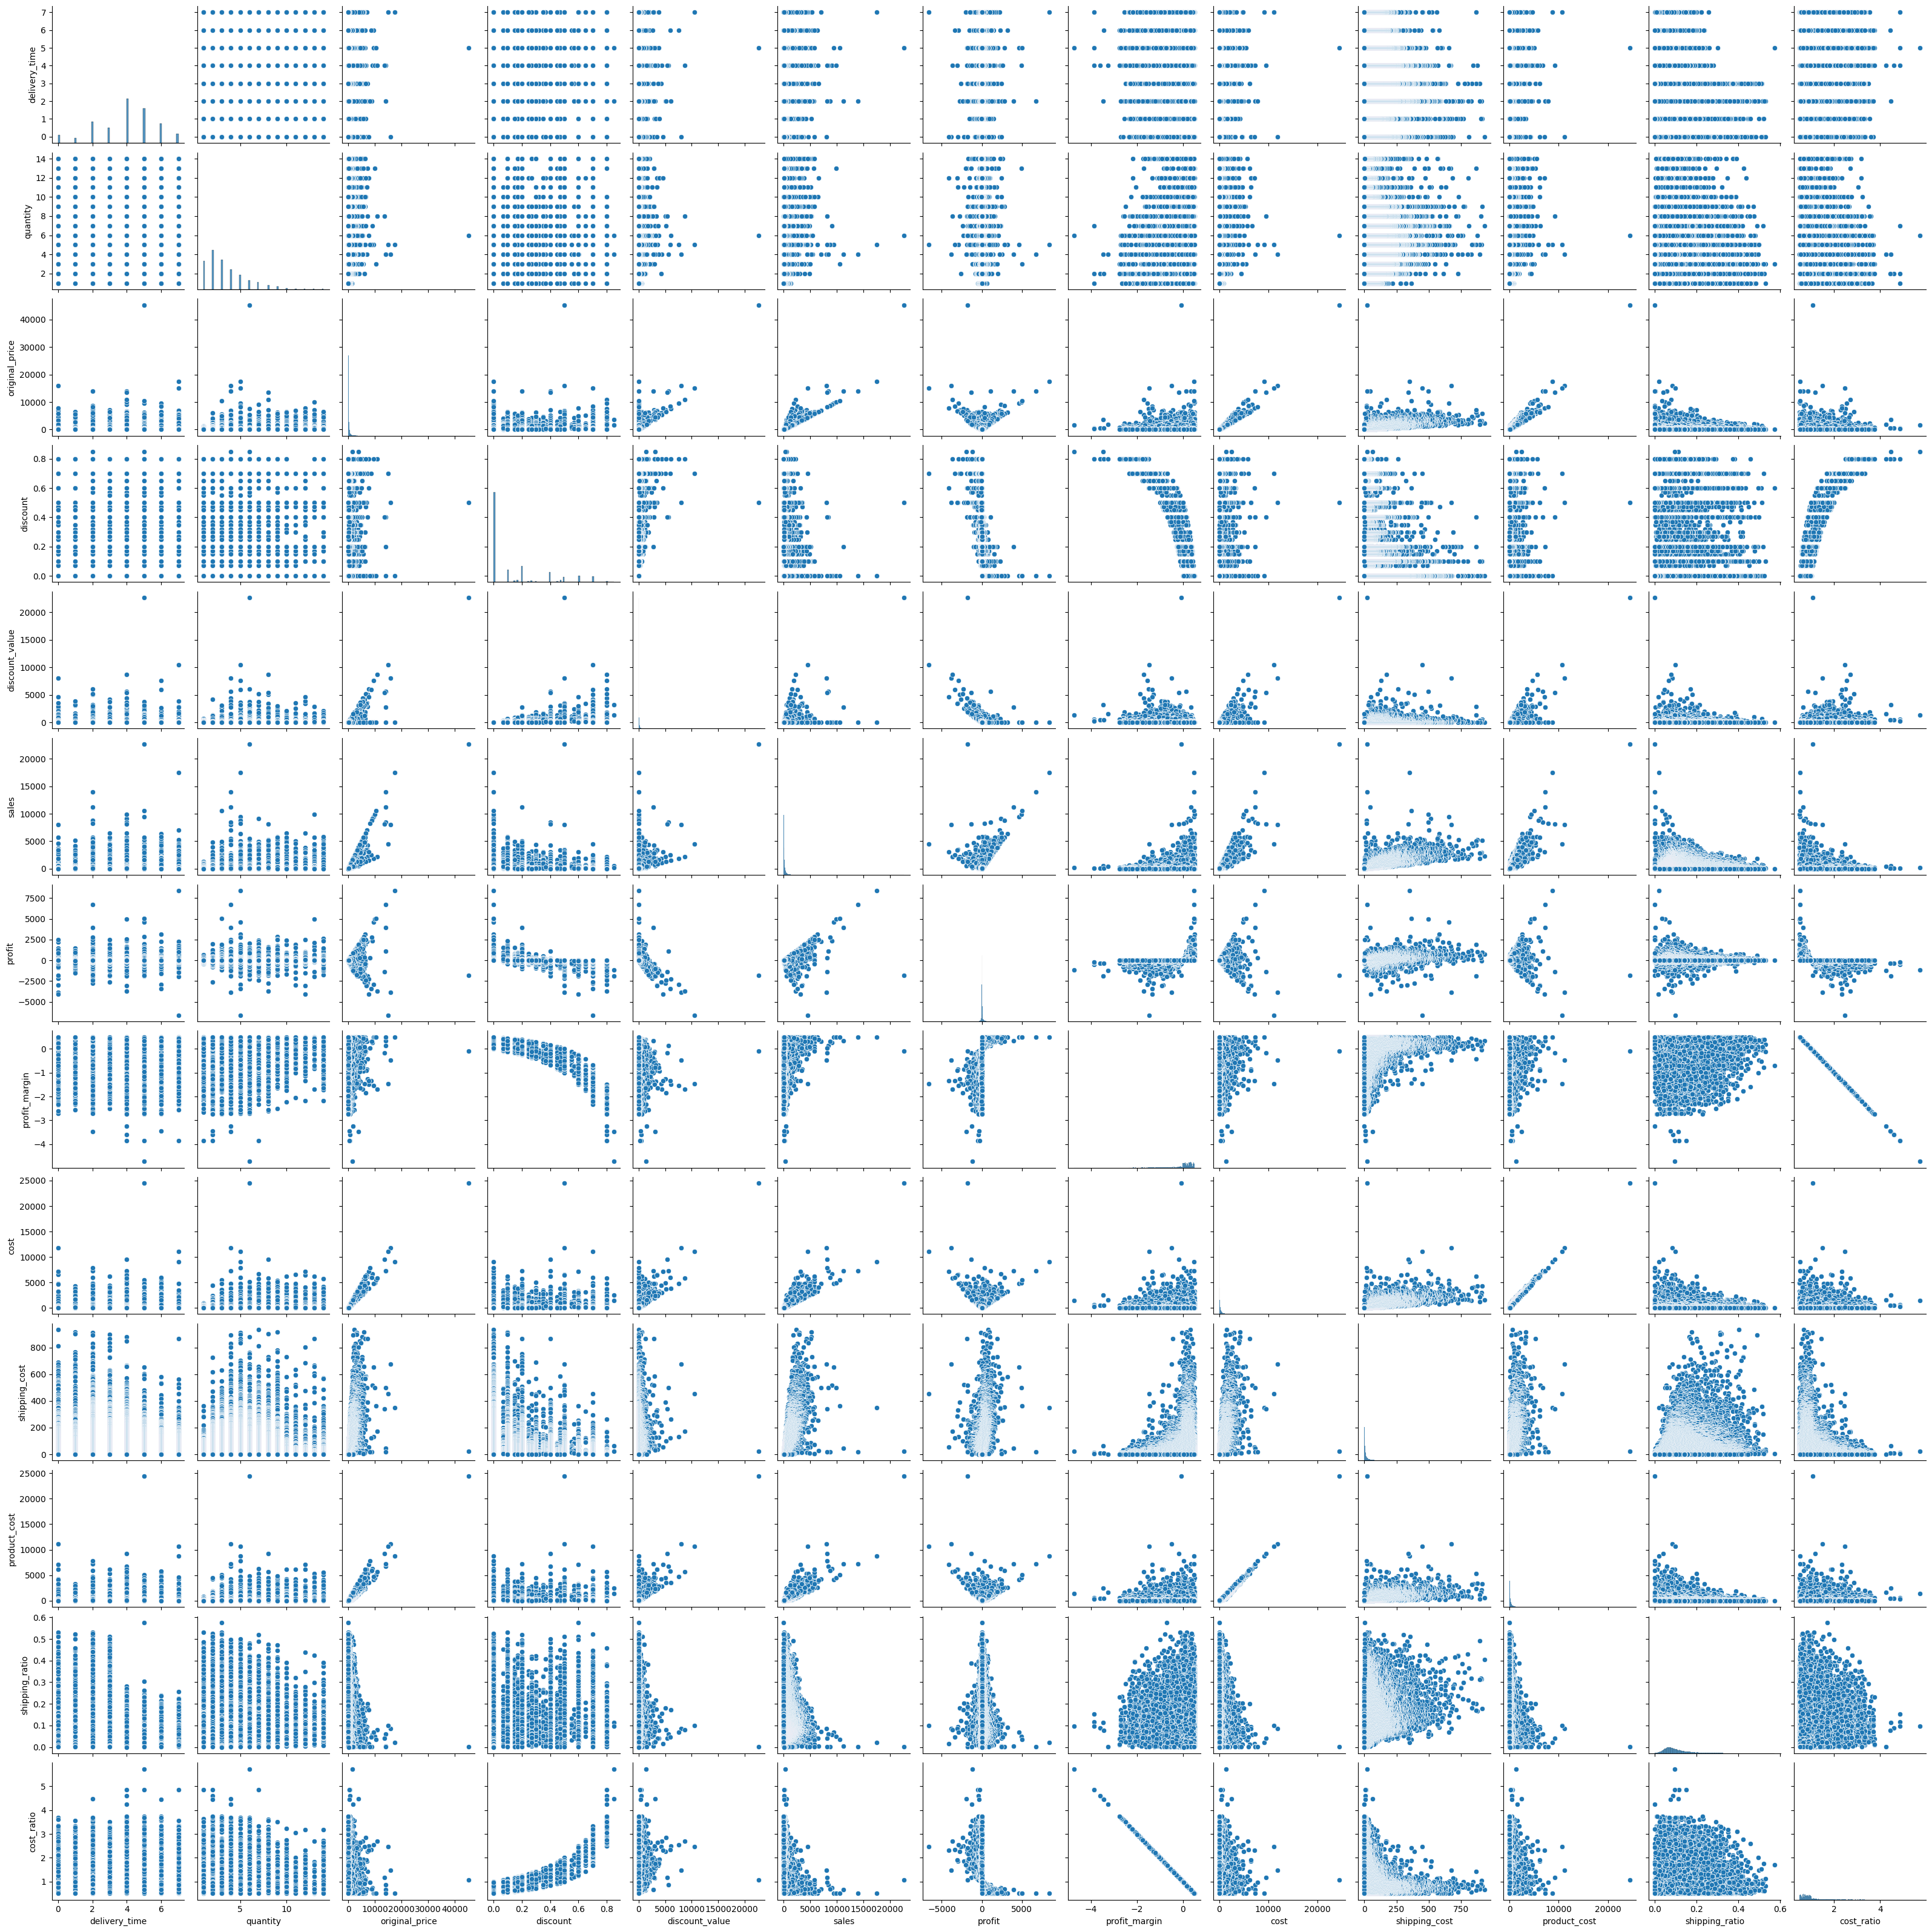

In [14]:
df = data_frame.loc[data_frame["returned"] == False].copy()

pairplot_df = df[[ "delivery_time", "quantity", "original_price", "discount",
    "discount_value", "sales", "profit", "profit_margin",
    "cost", "shipping_cost", "product_cost",
    "shipping_ratio", "cost_ratio"]]


sns.pairplot(data = pairplot_df)